# TF network figures

Fig. 2f and Supplementary Fig. S5d: for each TF perturbation with ≥ 3 rejected SCENIC+ targets and ≥ 1 rejected non-target (conjunction discoveries), the median |residual effect| of its targets and of its non-targets. Each panel is written to `figures/` (PDF); the values plotted in both go to one table in `data/` (CSV), with a `panel` column.

The notebook reads the frozen copy of `TF_RESULTS_DIR` (in `results_reference/`) by default. To plot a rerun, run `bash 8_TF_targets/run.sh` after stages 1, 2 and 5, then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `TF_RESULTS_DIR` in `results/`.

In [1]:
%matplotlib inline
import io
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import REPO_ROOT, TF_RESULTS_DIR, paper_name, reference

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

TF_RESULTS = reference(TF_RESULTS_DIR) if USE_REFERENCE else TF_RESULTS_DIR
MAGNITUDES = TF_RESULTS / "conjunction_residual_magnitude_by_TF.csv"

FIGURES = REPO_ROOT / "8_TF_targets" / "figures"
DATA = REPO_ROOT / "8_TF_targets" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

DISPLAY_DPI = 110  # inline previews only; the PDFs are vector

# Style of both panels.
STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "Arial"],
    "font.size": 7.0,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
}
TITLE_FONT, LABEL_FONT, TF_FONT = 8.2, 7.5, 7.0
TICK_FONT, LEGEND_FONT, COUNT_FONT = 6.8, 6.3, 6.6
C_UP, C_DOWN, C_REF = "#B64342", "#5B7C99", "#9A9A9A"  # targets larger, targets smaller, non-targets
SEGMENT_WIDTH, TARGET_MARKER_SIZE, OTHER_MARKER_SIZE = 1.15, 3.4, 4.1

MEDIANS = ["target_median_abs_effect", "non_target_median_abs_effect"]
MEANS = ["target_mean_abs_effect", "non_target_mean_abs_effect"]
FIRST_COLUMNS = [
    "panel", "display_dataset", "display_rank", "TF", *MEDIANS, "targets_vs_non_targets", "n_rejected_target_genes",
]


def panel_rows(source, panel, dataset, cell_line, finite=MEDIANS):
    """Plotted TFs of one dataset in one panel, top row first: plotted columns first, then the other input columns.

    TFs with >= 3 rejected targets and >= 1 rejected non-target, ordered by rejected-target
    count, then target/non-target median ratio, then name.
    """
    frame = source.loc[
        source.dataset.eq(dataset)
        & source.network.eq(f"SCENICplus_{cell_line}_active")
        & source.test.eq("conjunction")
        & source.effect_type.eq("residual")
        & source.condition.eq("conjunction_residual")
    ]
    rows = frame.loc[
        frame.n_rejected_target_genes.ge(3)
        & frame.n_rejected_non_target_genes.ge(1)
        & np.isfinite(frame[finite]).all(axis=1)
    ].copy()
    rows["median_ratio_for_order"] = rows.target_median_abs_effect / rows.non_target_median_abs_effect
    rows = rows.sort_values(
        ["n_rejected_target_genes", "median_ratio_for_order", "TF"], ascending=[False, False, True], kind="stable"
    ).reset_index(drop=True)
    rows["display_rank"] = np.arange(1, len(rows) + 1)
    rows["panel"] = panel
    # Marker colour: red ("larger") if the target median >= the non-target median, else blue ("smaller").
    rows["targets_vs_non_targets"] = np.where(
        rows.target_median_abs_effect >= rows.non_target_median_abs_effect, "larger", "smaller"
    )
    return rows[FIRST_COLUMNS + [column for column in rows.columns if column not in FIRST_COLUMNS]]


def draw_tf_rows(ax, rows, x_max, count_x):
    """One row per TF: non-target median (open) to target median (filled), DE-target count at the right."""
    yy = np.arange(len(rows))[::-1]
    for y, row in zip(yy, rows.itertuples(index=False)):
        target, other = row.target_median_abs_effect, row.non_target_median_abs_effect
        color = C_UP if target >= other else C_DOWN
        ax.plot([other, target], [y, y], color=color, lw=SEGMENT_WIDTH, solid_capstyle="round", zorder=2)
        ax.plot(other, y, marker="o", ls="none", ms=OTHER_MARKER_SIZE, mfc="white", mec=C_REF, mew=0.8, zorder=3)
        ax.plot(target, y, marker="o", ls="none", ms=TARGET_MARKER_SIZE, mfc=color, mec=color, mew=0.6, zorder=4)
        ax.text(count_x, y, str(row.n_rejected_target_genes), transform=ax.get_yaxis_transform(),
                ha="center", va="center", fontsize=COUNT_FONT, color="#333333", clip_on=False)
    ax.set_yticks(yy, labels=rows.TF, fontsize=TF_FONT)
    ax.set_ylim(-0.7, len(rows) - 0.1)
    ax.tick_params(axis="y", length=0, pad=2.2)
    ax.set_xlim(0.04, x_max)
    ax.set_xticks(np.arange(0.1, x_max + 0.001, 0.1))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.tick_params(axis="x", labelsize=TICK_FONT, length=2.4, width=0.6, pad=2.0)
    ax.grid(axis="x", color="#E6E6E6", linewidth=0.35)
    ax.set_axisbelow(True)
    ax.set_xlabel("Median |residual effect|", fontsize=LABEL_FONT, labelpad=3.0)


def legend_handles():
    return [
        Line2D([], [], marker="o", ls="none", ms=OTHER_MARKER_SIZE, mfc="white", mec=C_REF, mew=0.8, label="Non-targets"),
        Line2D([], [], marker="o", ls="none", ms=TARGET_MARKER_SIZE, mfc=C_UP, mec=C_UP, label="Targets, larger"),
        Line2D([], [], marker="o", ls="none", ms=TARGET_MARKER_SIZE, mfc=C_DOWN, mec=C_DOWN, label="Targets, smaller"),
    ]


def show_inline(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DISPLAY_DPI, facecolor="white")
    display(Image(data=buffer.getvalue()))

## Plotted values

Fig. 2f and S5d: `TF_RESULTS_DIR` (`conjunction_residual_magnitude_by_TF.csv`), from `8_TF_targets/compare_active_target_residual_magnitude.py`, one row per plotted TF in plotting order.

In [2]:
S5D_PANELS = [("Nadig-HEPG2", "HepG2"), ("Huang-HCT116", "HCT116")]  # (dataset, cell line)
source = pd.read_csv(MAGNITUDES)
magnitudes = pd.concat(
    # The Fig 2f script also required finite target and non-target means.
    [panel_rows(source, "Fig. 2f", "Replogle-GW-k562", "K562", finite=MEANS + MEDIANS)]
    + [panel_rows(source, "Supplementary Fig. S5d", dataset, cell_line) for dataset, cell_line in S5D_PANELS],
    ignore_index=True,
)
magnitudes.to_csv(DATA / "TF_target_residual_magnitude.csv", index=False)

## Fig. 2f — SCENIC+ K562-active targets

Replogle-GW-K562 with the K562-active network: the `Fig. 2f` rows of the table.

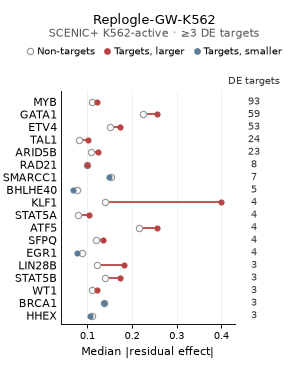

In [3]:
fig2f = magnitudes[magnitudes["panel"].eq("Fig. 2f")]

# Start from the matplotlibrc defaults, as the panel script did.
mpl.rc_file_defaults()
mpl.rcParams.update(STYLE)

# 71.2 mm wide; the plot height follows the row count (mm).
WIDTH_MM, LEFT_MM, RIGHT_MM, BOTTOM_MM, TOP_MM = 71.2, 14.0, 17.0, 14.0, 21.0
plot_height = max(18.0, 3.0 * len(fig2f))
height = TOP_MM + BOTTOM_MM + plot_height
figure = plt.figure(figsize=(WIDTH_MM / 25.4, height / 25.4))
ax = figure.add_axes([
    LEFT_MM / WIDTH_MM,
    BOTTOM_MM / height,
    (WIDTH_MM - LEFT_MM - RIGHT_MM) / WIDTH_MM,
    plot_height / height,
])
draw_tf_rows(ax, fig2f, x_max=0.43, count_x=1.11)
ax.text(1.11, 1.018, "DE targets", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=COUNT_FONT, color="#333333", clip_on=False)
figure.text(0.50, 1 - 3.1 / height, paper_name("Replogle-GW-k562"), ha="center", va="top", fontsize=TITLE_FONT)
figure.text(0.50, 1 - 6.7 / height, "SCENIC+ K562-active · ≥3 DE targets",
            ha="center", va="top", fontsize=7.0, color="#555555")
figure.legend(handles=legend_handles(), loc="center", bbox_to_anchor=(0.50, 1 - 12.0 / height), ncol=3,
              fontsize=LEGEND_FONT, handlelength=0.8, handletextpad=0.30, columnspacing=0.9, borderpad=0)

show_inline(figure)
figure.savefig(FIGURES / "TF_target_residual_magnitude_K562.pdf", dpi=600)
plt.close(figure)

## Supplementary Fig. S5d — SCENIC+ HepG2- and HCT116-active targets

Nadig-HepG2 with the HepG2-active network and Huang-HCT116 with the HCT116-active network, on a common 0.04–0.60 x-axis: the `Supplementary Fig. S5d` rows of the table.

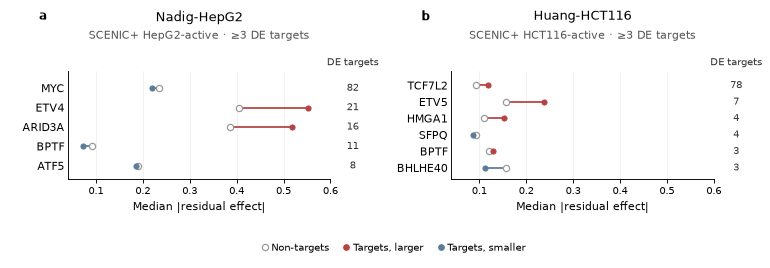

In [4]:
s5d = [
    magnitudes[magnitudes["panel"].eq("Supplementary Fig. S5d") & magnitudes["dataset"].eq(dataset)]
    for dataset, _ in S5D_PANELS
]

with mpl.rc_context(STYLE):
    figure, axes = plt.subplots(1, 2, figsize=(178.0 / 25.4, 62.0 / 25.4))
    figure.subplots_adjust(left=0.088, right=0.926, bottom=0.33, top=0.735, wspace=0.46)
    for letter, ax, rows, (dataset, cell_line) in zip("ab", axes, s5d, S5D_PANELS):
        draw_tf_rows(ax, rows, x_max=0.60, count_x=1.085)
        ax.text(1.085, 1.028, "DE targets", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=COUNT_FONT, color="#333333")
        position = ax.get_position()
        center = (position.x0 + position.x1) / 2
        figure.text(center, 0.96, paper_name(dataset), ha="center", va="top", fontsize=TITLE_FONT)
        figure.text(center, 0.884, f"SCENIC+ {cell_line}-active · ≥3 DE targets",
                    ha="center", va="top", fontsize=7.0, color="#555555")
        figure.text(position.x0 - 0.027, 0.96, letter, ha="right", va="top", fontsize=8, fontweight="bold")
    figure.legend(handles=legend_handles(), loc="center", bbox_to_anchor=(0.51, 0.075), ncol=3,
                  fontsize=LEGEND_FONT, handlelength=0.8, handletextpad=0.3, columnspacing=1.4, borderpad=0)
    figure.savefig(FIGURES / "TF_target_residual_magnitude_HepG2_HCT116.pdf", dpi=600)
    show_inline(figure)
    plt.close(figure)